# U01.LAB01 - SVM con Pipeline, Búsqueda de Parámetros y Evaluación

- **Pregunta de investigación:** ¿Es posible discriminar de forma reproducible entre tumores benignos y malignos a partir de morfología celular, minimizando los falsos negativos mediante un pipeline sin fuga?
- **Unidad de análisis:** Muestra de biopsia por aspiración con aguja fina (FNA) de tejido mamario.
- **Target:** Diagnóstico patológico (`0` = Maligno, `1` = Benigno).
- **Advertencia ética / clínica:** Este modelo se construye con propósitos académicos y de experimentación algorítmica; no constituye una herramienta de diagnóstico médico ni sustituye la evaluación clínica profesional.

In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

bunch = load_breast_cancer(as_frame=True)
X = bunch.data.copy()
y = bunch.target.copy()

print("Dimensiones de X:", X.shape)
print("\nDistribución del target (0 = Maligno, 1 = Benigno):")
print(y.value_counts().sort_index())
X.head()

Dimensiones de X: (569, 30)

Distribución del target (0 = Maligno, 1 = Benigno):
target
0    212
1    357
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [2]:
audit = pd.DataFrame(
    {
        "tipo": X.dtypes.astype(str),
        "ausentes": X.isna().sum(),
        "unicos": X.nunique(),
    }
)

print("Filas duplicadas:", X.duplicated().sum())
print("¿Target dentro de X?:", y.name in X.columns)
audit.head(10)

Filas duplicadas: 0
¿Target dentro de X?: False


,tipo,ausentes,unicos
mean radius,float64,0,456
mean texture,float64,0,479
mean perimeter,float64,0,522
mean area,float64,0,539
mean smoothness,float64,0,474
mean compactness,float64,0,537
mean concavity,float64,0,537
mean concave points,float64,0,542
mean symmetry,float64,0,432
mean fractal dimension,float64,0,499


### Hallazgos de la Auditoría Previa al Modelado

- **Ausencia de fuga de datos (Data Leakage):** Se comprobó que la variable objetivo no está presente dentro de la matriz de características (`Target dentro de X: False`), garantizando que el modelo no reciba información anticipada del diagnóstico.
- **Calidad e integridad de las observaciones:** El conjunto de datos presenta una integridad completa con 0 registros duplicados y 0 valores ausentes en las 30 variables predictoras evaluadas.
- **Balance del target:** Se observa una distribución moderadamente desbalanceada compuesta por 212 observaciones malignas (37.3%) y 357 benignas (62.7%). Por esta razón, la partición de datos y la validación cruzada deberán aplicar estratificación obligatoria, priorizando métricas como el **F1-macro** sobre el simple *accuracy*.
- **Criterio de conservación de variables:** Se conservan las 569 filas y las 30 características morfométricas originales en su totalidad, ya que todas aportan información geométrica y de textura del tejido celular sin justificación semántica para su exclusión.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("\nProporción de clases en Entrenamiento:")
print(y_train.value_counts(normalize=True).round(3))
print("\nProporción de clases en Prueba:")
print(y_test.value_counts(normalize=True).round(3))

Dimensiones de X_train: (455, 30)
Dimensiones de X_test: (114, 30)

Proporción de clases en Entrenamiento:
target
1    0.626
0    0.374
Name: proportion, dtype: float64

Proporción de clases en Prueba:
target
1    0.632
0    0.368
Name: proportion, dtype: float64


### Justificación Metodológica de la Partición

- **Prevención estricta de fuga (Data Leakage):** Se aísla el 20% de las observaciones (114 registros) como conjunto de prueba antes de cualquier etapa de preprocesamiento, garantizando una evaluación no contaminada del modelo final.
- **Estratificación representativa (`stratify=y`):** Se asegura que tanto el subconjunto de entrenamiento como el de prueba preserven exactamente la distribución original del target (~37.3% maligno y ~62.7% benigno), evitando sesgos de muestreo en la estimación de error.
- **Reproducibilidad:** Se fija la semilla pseudoaleatoria (`random_state=42`) para garantizar que la división sea exactamente reproducible en futuras ejecuciones.

In [5]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score

# Estrategia de asignar siempre la clase más frecuente (benigno = 1)
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_test)
dummy_f1 = f1_score(y_test, dummy_pred, average="macro")

print("F1 macro baseline (DummyClassifier):", dummy_f1)

F1 macro baseline (DummyClassifier): 0.3870967741935484


### Interpretación de la Línea Base (Baseline)

* **Puntaje F1 macro:** 0.3870967741935484.
* **Conclusión:** El modelo ingenuo solo predice la clase mayoritaria y falla el 100% de los casos malignos. Este valor de 0.3870967741935484 es el umbral mínimo que nuestro pipeline con SVM debe superar con holgura para demostrar que realmente está aprendiendo patrones a partir de los datos.

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Definición del pipeline con preprocesamiento y clasificador base
svm = Pipeline(
    [
        ("scale", StandardScaler()),
        ("model",SVC(kernel="rbf",C=1.0,gamma="scale",probability=True,random_state=42))
    ])

# Ajuste del pipeline sobre el conjunto de entrenamiento
svm.fit(X_train, y_train)

/workspaces/INF8239_U01/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scale', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['mean radius','mean texture','mean perimeter',...,'worst concave points', 'worst symmetry','worst fractal dimension']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


Reporte de Clasificación (SVM Base):

              precision    recall  f1-score   support

           0     0.9762    0.9762    0.9762        42
           1     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114

ROC-AUC: 0.9950



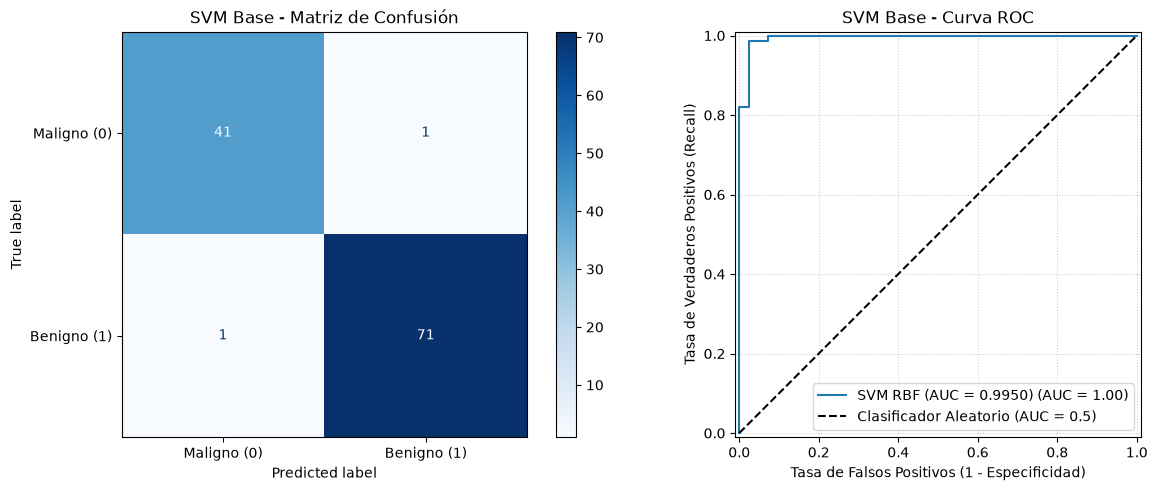

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    roc_auc_score,
)

# 1. Predicciones y probabilidades
pred = svm.predict(X_test)
proba = svm.predict_proba(X_test)[:, 1]

# 2. Reporte formal y ROC-AUC en consola
print("Reporte de Clasificación (SVM Base):\n")
print(classification_report(y_test, pred, digits=4))
roc_auc = roc_auc_score(y_test, proba)
print(f"ROC-AUC: {roc_auc:.4f}\n")

# 3. Subplots: Matriz de Confusión y Curva ROC
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Subgráfico 1: Matriz de Confusión
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred,
    display_labels=["Maligno (0)", "Benigno (1)"],
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title("SVM Base - Matriz de Confusión")
axes[0].grid(False)

# Subgráfico 2: Curva ROC
RocCurveDisplay.from_predictions(
    y_test,
    proba,
    name=f"SVM RBF (AUC = {roc_auc:.4f})",
    ax=axes[1],
)
axes[1].plot([0, 1], [0, 1], "k--", label="Clasificador Aleatorio (AUC = 0.5)")
axes[1].set_title("SVM Base - Curva ROC")
axes[1].set_xlabel("Tasa de Falsos Positivos (1 - Especificidad)")
axes[1].set_ylabel("Tasa de Verdaderos Positivos (Recall)")
axes[1].legend(loc="lower right")
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

### Análisis de Errores y Costo Clínico (SVM Base)

* **Conteo de falsos positivos y falsos negativos:**
  * **Falsos Negativos (1 caso):** Se clasificó como benigno (`1`) a un tumor que en realidad era maligno (`0`).
  * **Falsos Positivos (1 caso):** Se clasificó como maligno (`0`) a un tejido que era benigno (`1`).
  * En total, el modelo acertó 112 de las 114 observaciones del conjunto de prueba.

* **Evaluación del error más costoso en el contexto clínico:**
  * El error más crítico y costoso es el **falso negativo**. Catalogar a un paciente con tumor maligno como benigno retrasa intervenciones quirúrgicas o tratamientos oncológicos oportunos, comprometiendo directamente el pronóstico y la vida del paciente.
  * Un falso positivo genera ansiedad y conduce a biopsias o pruebas invasivas adicionales, pero no pone en riesgo inmediato la vida por falta de atención médica.


In [12]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# 1. Definir estrategia de validación cruzada estratificada (5 folds)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Configurar la rejilla de parámetros para el paso "model" del Pipeline
param_grid = {
    "model__C": [0.1, 1, 10],
    "model__gamma": ["scale", 0.01, 0.1],
}

# 3. Instanciar GridSearchCV optimizando F1-macro
search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)

# 4. Ajustar exclusivamente sobre el conjunto de entrenamiento
search.fit(X_train, y_train)

print("Mejores parámetros encontrados:")
print(search.best_params_)
print(f"\nMejor F1-macro promedio en validación cruzada: {search.best_score_:.4f}")

/workspaces/INF8239_U01/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/workspaces/INF8239_U01/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/workspaces/INF8239_U01/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/workspaces/INF8239_U01/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter

Mejores parámetros encontrados:
{'model__C': 10, 'model__gamma': 0.01}

Mejor F1-macro promedio en validación cruzada: 0.9739


/workspaces/INF8239_U01/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [13]:
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Silenciar FutureWarnings y advertencias de convergencia repetitivas
warnings.filterwarnings("ignore", category=FutureWarning)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "model__C": [0.1, 1, 10],
    "model__gamma": ["scale", 0.01, 0.1],
}

search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)

search.fit(X_train, y_train)

print("Mejores parámetros encontrados:")
print(search.best_params_)
print(f"\nMejor F1-macro promedio en validación cruzada: {search.best_score_:.4f}")

Mejores parámetros encontrados:
{'model__C': 10, 'model__gamma': 0.01}

Mejor F1-macro promedio en validación cruzada: 0.9739


In [14]:
cv_results = pd.DataFrame(search.cv_results_)
columns = [
    "param_model__C",
    "param_model__gamma",
    "mean_test_score",
    "std_test_score",
    "mean_fit_time",
]

display(cv_results[columns].sort_values("mean_test_score", ascending=False).head(9))

best = search.best_estimator_
best_pred = best.predict(X_test)
print(classification_report(y_test, best_pred, digits=4))

,param_model__C,param_model__gamma,mean_test_score,std_test_score,mean_fit_time
7,10.0,0.01,0.973888,0.017677,0.015833
4,1.0,0.01,0.969041,0.016283,0.031722
6,10.0,scale,0.967086,0.013638,0.022734
3,1.0,scale,0.966940,0.015966,0.026405
5,1.0,0.1,0.953323,0.012853,0.032334
1,0.1,0.01,0.942078,0.014347,0.030304
0,0.1,scale,0.937715,0.018035,0.064327
8,10.0,0.1,0.937532,0.023718,0.029155
2,0.1,0.1,0.934135,0.015687,0.040739


              precision    recall  f1-score   support

           0     0.9762    0.9762    0.9762        42
           1     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114



<>:31: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:31: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
/tmp/ipykernel_35151/1648145195.py:31: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  f"C={c}, $\gamma$={g}"


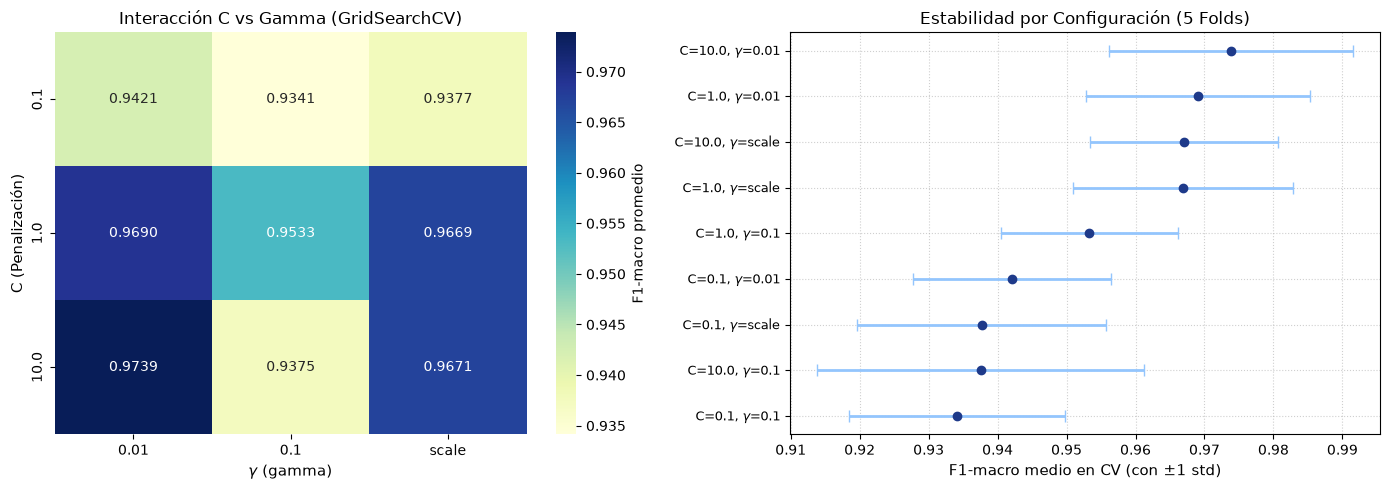

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Preparar datos para el Heatmap (pivoteando C vs gamma)
pivot_scores = cv_results.pivot(
    index="param_model__C",
    columns="param_model__gamma",
    values="mean_test_score",
)

# 2. Configurar la figura con dos subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Heatmap de F1-macro en CV
sns.heatmap(
    pivot_scores,
    annot=True,
    fmt=".4f",
    cmap="YlGnBu",
    cbar_kws={"label": "F1-macro promedio"},
    ax=axes[0],
)
axes[0].set_title("Interacción C vs Gamma (GridSearchCV)", fontsize=12)
axes[0].set_xlabel(r"$\gamma$ (gamma)", fontsize=11)
axes[0].set_ylabel("C (Penalización)", fontsize=11)

# Gráfico 2: Desempeño ordenado con barras de error (mean ± std)
cv_sorted = cv_results.sort_values("mean_test_score", ascending=True)
labels = [
    f"C={c}, $\gamma$={g}"
    for c, g in zip(cv_sorted["param_model__C"], cv_sorted["param_model__gamma"])
]

axes[1].errorbar(
    cv_sorted["mean_test_score"],
    range(len(cv_sorted)),
    xerr=cv_sorted["std_test_score"],
    fmt="o",
    color="#1E3A8A",
    ecolor="#93C5FD",
    elinewidth=2,
    capsize=4,
)
axes[1].set_yticks(range(len(cv_sorted)))
axes[1].set_yticklabels(labels, fontsize=9)
axes[1].set_xlabel("F1-macro medio en CV (con ±1 std)", fontsize=11)
axes[1].set_title("Estabilidad por Configuración (5 Folds)", fontsize=12)
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

In [16]:
from pathlib import Path
import joblib

Path("reports").mkdir(exist_ok=True)
cv_results[columns].to_csv("reports/svm_cv_results.csv", index=False)
joblib.dump(best, "reports/svm_best.joblib")

['reports/svm_best.joblib']

In [17]:
from pathlib import Path
import joblib

# Resolver la ruta hacia la raíz del proyecto (un nivel arriba de /notebooks)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
reports_dir = PROJECT_ROOT / "reports"
reports_dir.mkdir(exist_ok=True)

# Guardar los artefactos en la carpeta reports/ de la raíz
cv_results[columns].to_csv(reports_dir / "svm_cv_results.csv", index=False)
joblib.dump(best, reports_dir / "svm_best.joblib")

print(f"Archivos guardados exitosamente en: {reports_dir.resolve()}")

Archivos guardados exitosamente en: /workspaces/INF8239_U01/reports
